In [2]:
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Resolve project root dynamically
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = BASE_DIR / "data" / "fraud_db.db"

conn = sqlite3.connect(DB_PATH)
print("Connected to database successfully:", DB_PATH.exists())

Connected to database successfully: True


In [3]:
# Query engineered features view from SQLite
query = "SELECT * FROM v_fraud_engineered_features"
df = pd.read_sql(query, conn)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (100, 9)


,user_id,transaction_timestamp,Amount,Class,prev_transaction_time,rolling_avg_7d_amount,user_spend_rank,seconds_since_last_txn,amount_to_rolling_avg_ratio
0,1000,2026-01-01 23:06:51,165.69,0,NaN,165.690000,1,NaN,1.000000
1,1001,2026-01-01 03:45:45,2.08,0,NaN,2.080000,4,NaN,1.000000
2,1001,2026-01-01 06:03:54,12.84,0,2026-01-01 03:45:45,7.460000,2,8289.0,1.721180
3,1001,2026-01-01 12:56:16,4.39,0,2026-01-01 06:03:54,6.436667,3,24742.0,0.682030
4,1001,2026-01-01 15:30:20,19.68,0,2026-01-01 12:56:16,9.747500,1,9244.0,2.018979


C:\Users\DELL\AppData\Local\Temp\ipykernel_14144\1190974312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette=["#2ecc71", "#e74c3c"])


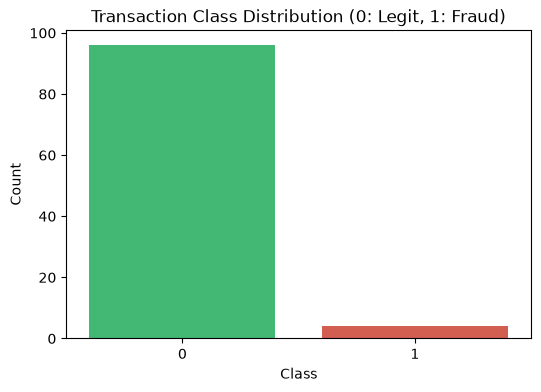

Total Fraud Cases: 4 (4.00%)


In [4]:
# Visualize Fraud vs Legit distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class", palette=["#2ecc71", "#e74c3c"])
plt.title("Transaction Class Distribution (0: Legit, 1: Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

fraud_pct = (df["Class"].sum() / len(df)) * 100
print(f"Total Fraud Cases: {df['Class'].sum()} ({fraud_pct:.2f}%)")

C:\Users\DELL\AppData\Local\Temp\ipykernel_14144\1764684636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
C:\Users\DELL\AppData\Local\Temp\ipykernel_14144\1764684636.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="amount_to_rolling_avg_ratio", ax=axes[1], palette=["#2ecc71", "#e74c3c"])


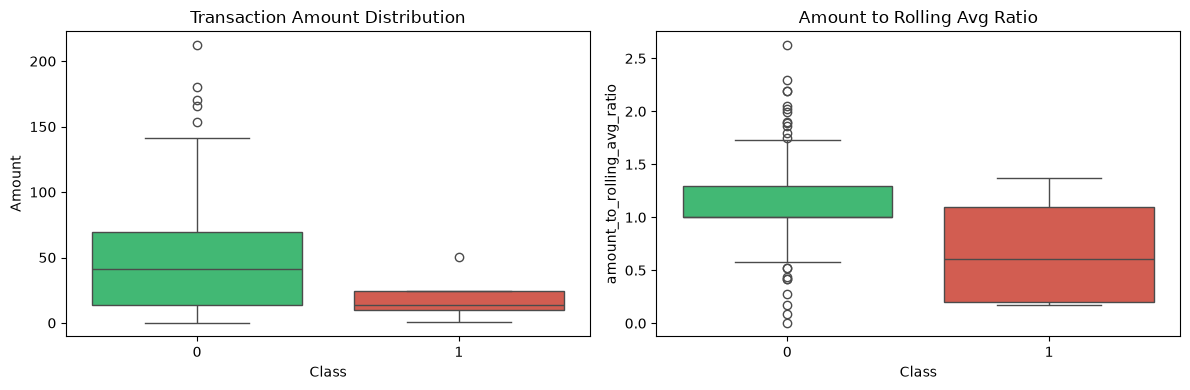

In [5]:
# Distribution comparisons
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Transaction Amount Distribution")

sns.boxplot(data=df, x="Class", y="amount_to_rolling_avg_ratio", ax=axes[1], palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Amount to Rolling Avg Ratio")

plt.tight_layout()
plt.show()

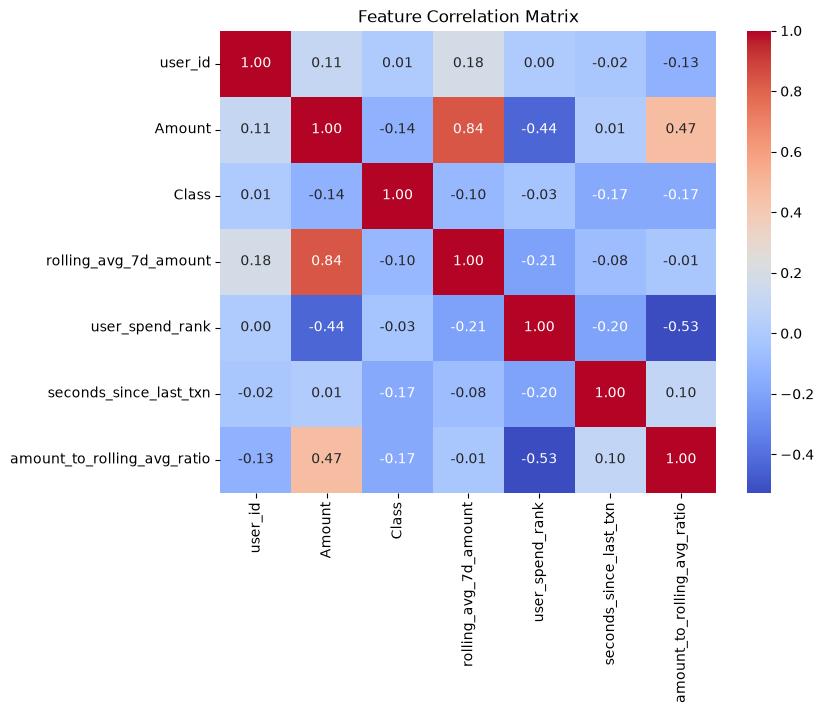

In [6]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()